In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_products.csv")

In [2]:
print(df.head())

                product_name brand_name  rating  price_usd  \
0    Fragrance Discovery Set      19-69  3.6364       35.0   
1    La Habana Eau de Parfum      19-69  4.1538      195.0   
2  Rainbow Bar Eau de Parfum      19-69  4.2500      195.0   
3       Kasbah Eau de Parfum      19-69  4.4762      195.0   
4  Purple Haze Eau de Parfum      19-69  3.2308      195.0   

                                         ingredients primary_category  \
0  ['Capri Eau de Parfum:', 'Alcohol Denat. (SD A...        Fragrance   
1  ['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...        Fragrance   
2  ['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...        Fragrance   
3  ['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...        Fragrance   
4  ['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...        Fragrance   

  secondary_category  loves_count  
0  Value & Gift Sets         6320  
1              Women         3827  
2              Women         3253  
3              Women         3018  
4       

In [4]:
print(df.shape)

(8216, 8)


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8216 entries, 0 to 8215
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_name        8216 non-null   object 
 1   brand_name          8216 non-null   object 
 2   rating              8216 non-null   float64
 3   price_usd           8216 non-null   float64
 4   ingredients         7322 non-null   object 
 5   primary_category    8216 non-null   object 
 6   secondary_category  8209 non-null   object 
 7   loves_count         8216 non-null   int64  
dtypes: float64(2), int64(1), object(5)
memory usage: 513.6+ KB
None


In [6]:
top_brands = (
    df["brand_name"]
    .value_counts()
    .head(10)
              )

print(top_brands)

brand_name
SEPHORA COLLECTION         351
CLINIQUE                   177
Dior                       133
tarte                      126
Kérastase                  107
Bumble and bumble          107
Charlotte Tilbury           98
TOM FORD                    97
Anastasia Beverly Hills     94
NEST New York               92
Name: count, dtype: int64


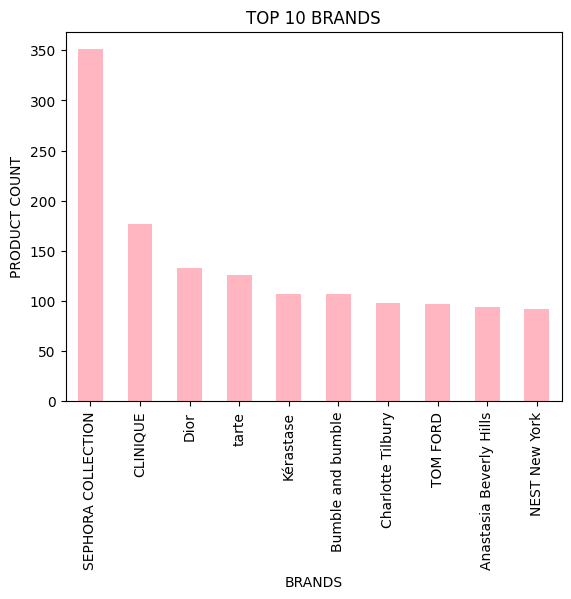

In [16]:
import matplotlib.pyplot as plt 
top_brands.plot(
    kind="bar",
    color="lightpink"
    )     
plt.title("TOP 10 BRANDS")
plt.xlabel("BRANDS")
plt.ylabel("PRODUCT COUNT")
plt.show()

In [18]:
top_rated = (
    df.groupby("brand_name")["rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(top_rated)

brand_name
Erno Laszlo            5.000000
Aquis                  4.904800
MACRENE actives        4.889420
MARA                   4.823860
CANOPY                 4.813733
DOMINIQUE COSMETICS    4.785700
BondiBoost             4.776950
DAMDAM                 4.752775
Kate McLeod            4.751583
maude                  4.740100
Name: rating, dtype: float64


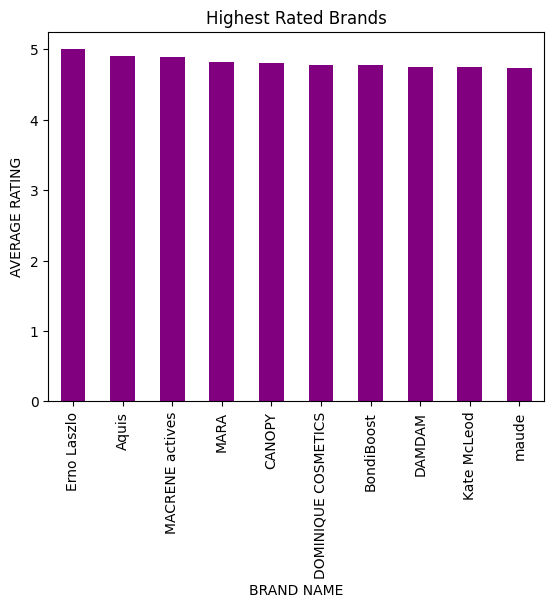

In [23]:
import matplotlib.pyplot as plt
top_rated.plot(
    kind="bar",
    color="purple"
)

plt.title("Highest Rated Brands")

plt.ylabel("AVERAGE RATING")
plt.xlabel("BRAND NAME")
plt.show()

In [24]:
category_counts = (
    df["primary_category"]
    .value_counts()
)

print(category_counts)

primary_category
Skincare           2351
Makeup             2328
Hair               1416
Fragrance          1339
Bath & Body         395
Mini Size           274
Men                  59
Tools & Brushes      50
Gifts                 4
Name: count, dtype: int64


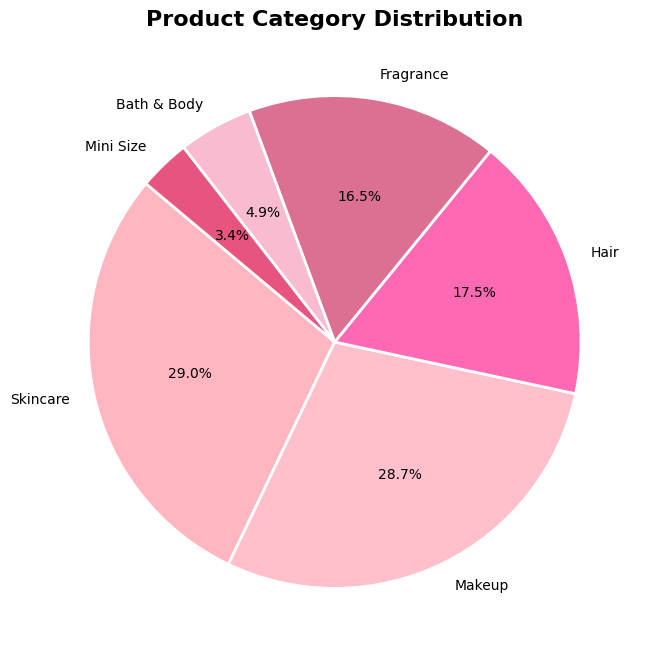

In [33]:
import matplotlib.pyplot as plt

# Count categories
category_counts = (
    df["primary_category"]
    .value_counts()
)

# Keep top categories only
top_categories = category_counts.head(6)

# Create pink palette
colors = [
    "#FFB6C1",
    "#FFC0CB",
    "#FF69B4",
    "#DB7093",
    "#F8BBD0",
    "#E75480"
]

# Plot
plt.figure(figsize=(8,8))

plt.pie(
    top_categories,
    labels=top_categories.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2
    }
)

plt.title(
    "Product Category Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [ ]:
#PRICE ANALYSIS
print(
    df["price_usd"].mean()
)

51.22822906523856


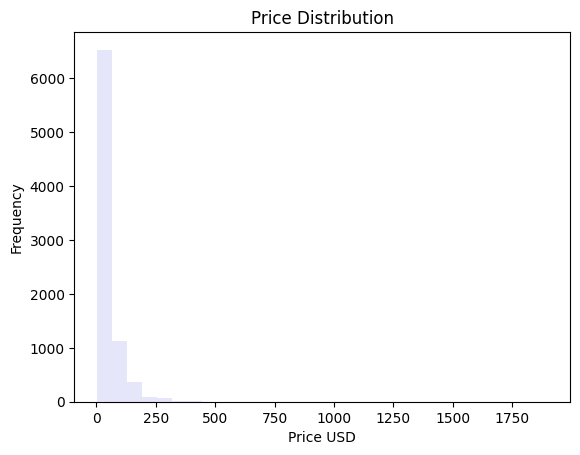

In [37]:
#PRICE DISTRIBUTION
df["price_usd"].plot(
    kind="hist",
    color="lavender",
    bins=30
)

plt.title("Price Distribution")

plt.xlabel("Price USD")

plt.show()

In [38]:
#MOST LOVED PRODUCTS
most_loved = (
    df.sort_values(
        by="loves_count",
        ascending=False
    )
    .head(10)
)

print(
    most_loved[
        [
            "product_name",
            "brand_name",
            "loves_count"
        ]
    ]
)

                                           product_name  \
6035                            Soft Pinch Liquid Blush   
5103                           Radiant Creamy Concealer   
4307  Lip Sleeping Mask Intense Hydration with Vitam...   
6222                    Cream Lip Stain Liquid Lipstick   
2448                 Gloss Bomb Universal Lip Luminizer   
2449   Pro Filt’r Soft Matte Longwear Liquid Foundation   
5104                                              Blush   
237           Brow Wiz Ultra-Slim Precision Brow Pencil   
4334                   Translucent Loose Setting Powder   
7392        Niacinamide 10% + Zinc 1% Oil Control Serum   

                       brand_name  loves_count  
6035  Rare Beauty by Selena Gomez      1401068  
5103                         NARS      1153594  
4307                      LANEIGE      1081315  
6222           SEPHORA COLLECTION      1029051  
2448      Fenty Beauty by Rihanna       968317  
2449      Fenty Beauty by Rihanna       856497  
5104   

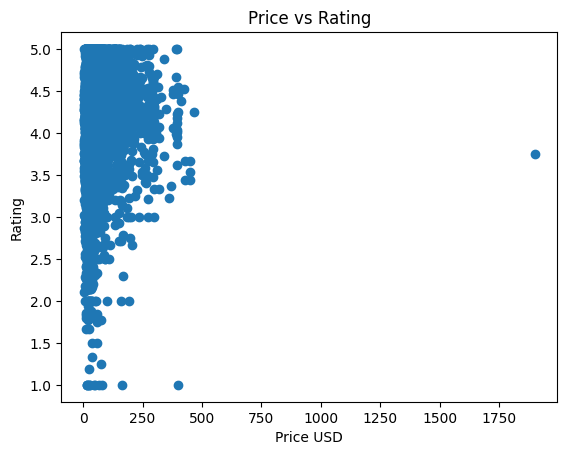

In [39]:
#PRICE VS RATING ANALYSIS
plt.scatter(
    df["price_usd"],
    df["rating"]
)

plt.xlabel("Price USD")

plt.ylabel("Rating")

plt.title("Price vs Rating")

plt.show()

In [40]:
#MOST COMMON INGREDIENTS
all_ingredients = (
    " ".join(
        df["ingredients"]
        .dropna()
        .astype(str)
    )
)

In [41]:
from wordcloud import WordCloud

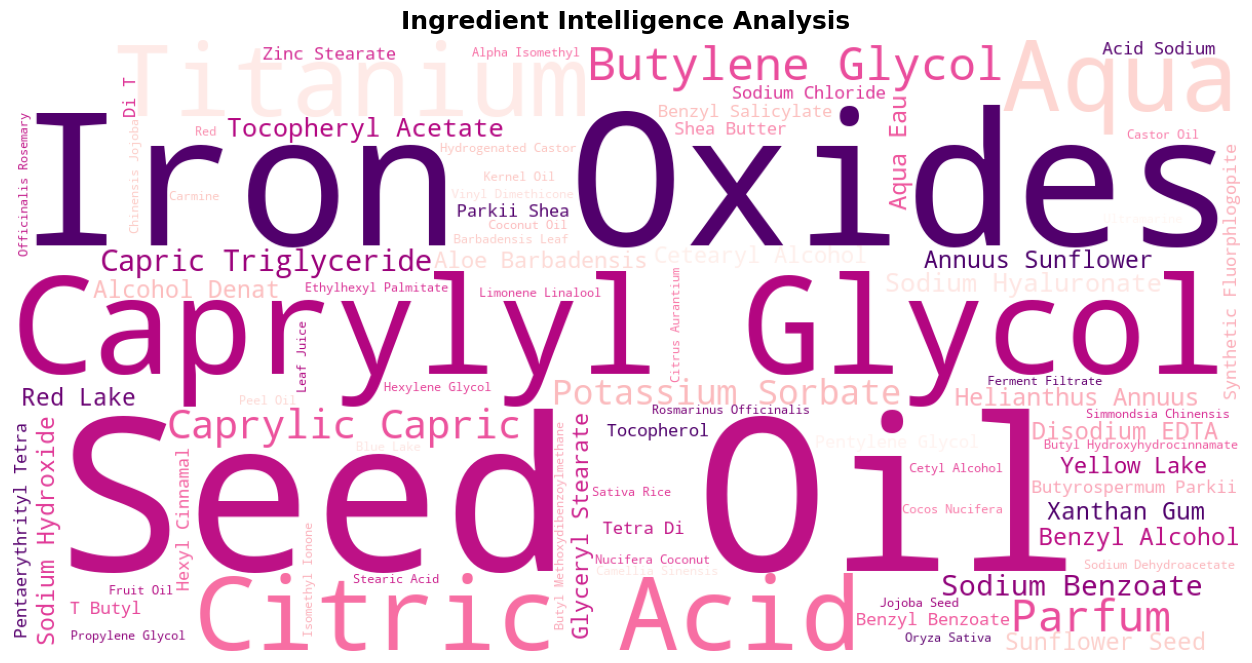

In [43]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Combine ingredients
text = " ".join(
    df["ingredients"]
    .dropna()
    .astype(str)
)

# Custom stopwords
custom_stopwords = set(STOPWORDS)

custom_stopwords.update([
    "water",
    "ci",
    "oxide",
    "dioxide",
    "extract",
    "fragrance",
    "may",
    "contain"
])

# Generate cleaner word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="RdPu",
    max_words=80
).generate(text)

# Plot
plt.figure(figsize=(16,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Ingredient Intelligence Analysis",
    fontsize=18,
    fontweight="bold"
)

plt.show()